In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

df = pd.read_csv("../data/preprocessed_customer_data.csv")
df.head()


,customer_id,total_spent,total_orders,last_purchase,recency,avg_order_value
0,00012a2ce6f8dcda20d059ce98491703,1950.58,1,2017-11-14 16:08:26,287,1950.58
1,000161a058600d5901f007fab4c27140,1145.97,1,2017-07-16 09:40:32,409,1145.97
2,0001fd6190edaaf884bcaf3d49edf079,3322.14,1,2017-02-28 11:06:43,547,3322.14
3,0002414f95344307404f0ace7a26f1d5,3048.95,1,2017-08-16 13:09:20,378,3048.95
4,000379cdec625522490c315e70c7a9fb,1819.17,1,2018-04-02 13:42:17,149,1819.17


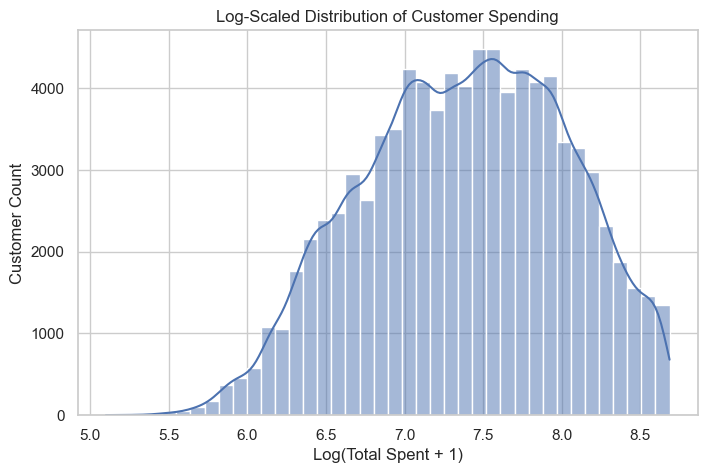

In [3]:
#Spending Distribution (Log-Scale Insight)
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['total_spent']), bins=40, kde=True)
plt.title("Log-Scaled Distribution of Customer Spending")
plt.xlabel("Log(Total Spent + 1)")
plt.ylabel("Customer Count")
plt.show()


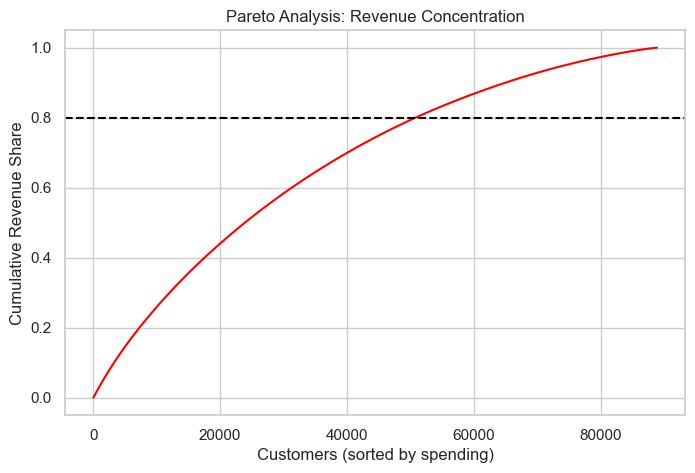

In [4]:
#Pareto Analysis
pareto = df[['customer_id','total_spent']].sort_values(
    by='total_spent', ascending=False
)

pareto['cum_revenue'] = pareto['total_spent'].cumsum()
pareto['cum_percentage'] = pareto['cum_revenue'] / pareto['total_spent'].sum()

plt.figure(figsize=(8,5))
plt.plot(pareto['cum_percentage'].values, color='red')
plt.axhline(0.8, linestyle='--', color='black')
plt.title("Pareto Analysis: Revenue Concentration")
plt.xlabel("Customers (sorted by spending)")
plt.ylabel("Cumulative Revenue Share")
plt.show()


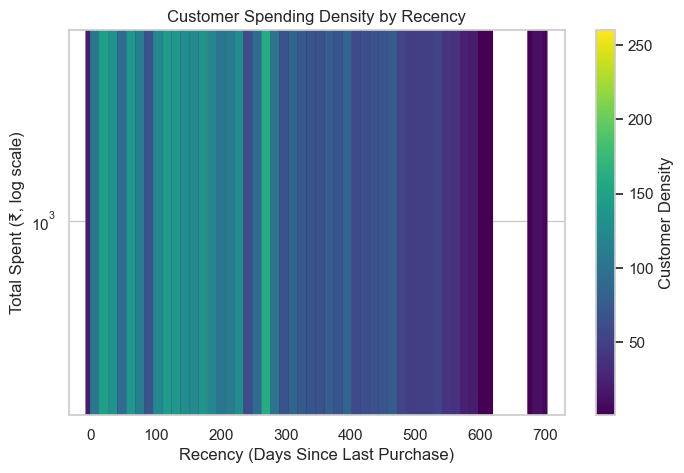

In [14]:
# Spending Density Across Customer Recency
plt.figure(figsize=(8,5))
plt.hexbin(
    df['recency'],
    df['total_spent'],
    gridsize=50,
    cmap='viridis',
    mincnt=1
)
plt.colorbar(label='Customer Density')
plt.yscale('log')
plt.title("Customer Spending Density by Recency")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Total Spent (₹, log scale)")
plt.show()


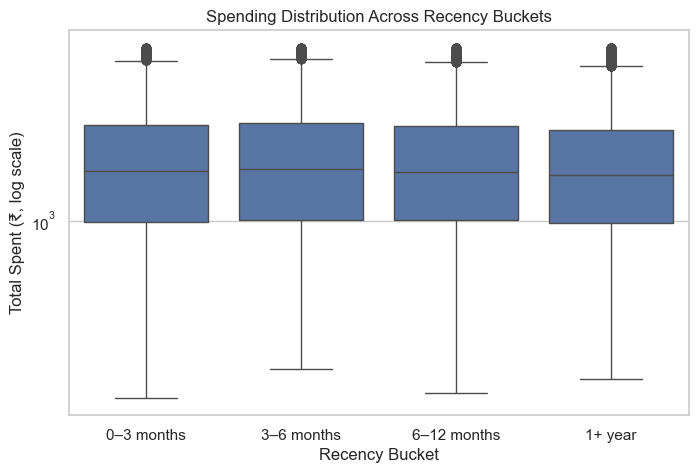

In [13]:
# Spending vs Frequency colored by recency
# Create recency buckets
df['recency_bucket'] = pd.cut(
    df['recency'],
    bins=[0, 90, 180, 365, 700],
    labels=['0–3 months', '3–6 months', '6–12 months', '1+ year']
)

plt.figure(figsize=(8,5))
sns.boxplot(
    x='recency_bucket',
    y='total_spent',
    data=df
)
plt.yscale('log')
plt.title("Spending Distribution Across Recency Buckets")
plt.xlabel("Recency Bucket")
plt.ylabel("Total Spent (₹, log scale)")
plt.show()




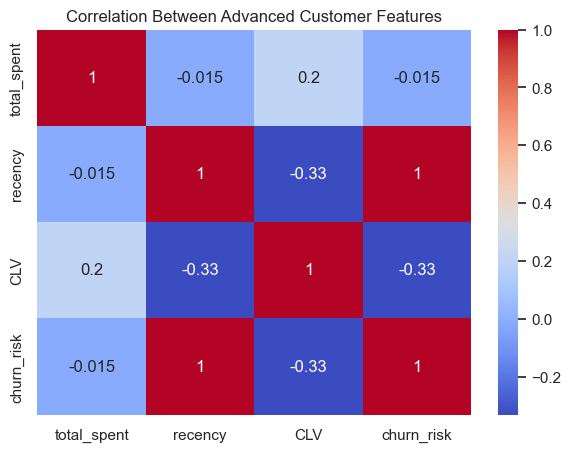

In [11]:
# Feature Relationship Heatmap
df['CLV'] = (
    df['avg_order_value'] *
    df['total_orders'] *
    (1 / (df['recency'] + 1))
)
df['churn_risk'] = (
    (df['recency'] / df['recency'].max()) * 0.6 +
    (1 - df['total_orders'] / df['total_orders'].max()) * 0.4
)
plt.figure(figsize=(7,5))
sns.heatmap(
    df[['total_spent', 'recency', 'CLV', 'churn_risk']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Advanced Customer Features")
plt.show()


C:\Users\Allan\AppData\Local\Temp\ipykernel_21984\2633978351.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('segment')['total_spent']
C:\Users\Allan\AppData\Local\Temp\ipykernel_21984\2633978351.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


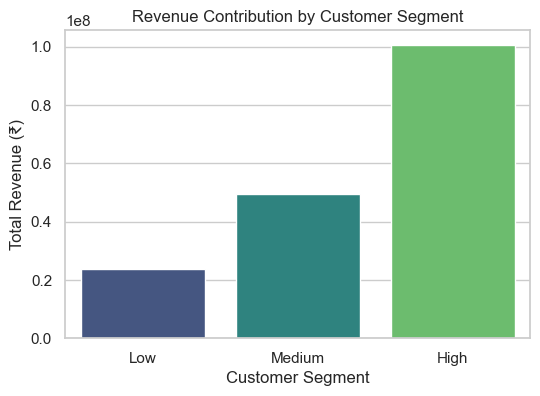

In [10]:
# Customer Value Segmentation
segment_revenue = (
    df.groupby('segment')['total_spent']
    .sum()
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    x='segment',
    y='total_spent',
    data=segment_revenue,
    palette='viridis'
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (₹)")
plt.show()
